In [6]:
# Download fruit dataset from GitHub

!wget https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip

--2026-03-11 09:49:46--  https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master [following]
--2026-03-11 09:49:46--  https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [          <=>       ] 761.30M  18.1MB/s    in 43s     

2026-03-11 09:50:30 (17.8 MB/s) - ‘master.zip’ saved [798281972]



In [7]:
!ls

master.zip  sample_data


In [8]:
!unzip master.zip

Streaming output truncated to the last 5000 lines.
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/147_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/148_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/149_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/150_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/151_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/152_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/153_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/154_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/155_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/156_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/157_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/158_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/159_100.jpg  


In [9]:
!ls

Fruit-Images-Dataset-master  master.zip  sample_data


In [10]:
!ls Fruit-Images-Dataset-master

LICENSE  papers  readme.md  src  Test  test-multiple_fruits  Training


In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# DATASET SETTINGS

IMG_SIZE = 64

classes = [
    "Apple Braeburn",
    "Banana",
    "Orange",
    "Mango"
]

TRAIN_PATH = "Fruit-Images-Dataset-master/Training"
TEST_PATH = "Fruit-Images-Dataset-master/Test"



In [17]:
# LOAD DATASET

def load_data(data_path, limit=80):

    data = []
    labels = []

    for label, category in enumerate(classes):

        folder = os.path.join(data_path, category)

        count = 0

        for img_name in os.listdir(folder):

            if count >= limit:
                break

            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            img = img / 255.0

            data.append(img)
            labels.append(label)

            count += 1

    data = np.array(data).reshape(-1,1,IMG_SIZE,IMG_SIZE)
    labels = np.array(labels)

    return data, labels



In [18]:
# LOAD TRAINING & TEST DATA

X_train, y_train = load_data(TRAIN_PATH, limit=80)
X_test, y_test = load_data(TEST_PATH, limit=40)

print("Train Shape:",X_train.shape)
print("Test Shape:",X_test.shape)


Train Shape: (320, 1, 64, 64)
Test Shape: (160, 1, 64, 64)


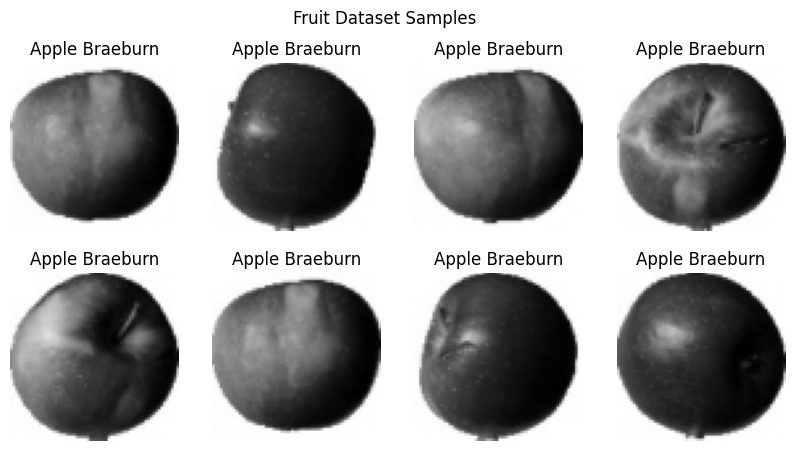

In [19]:
# DATASET VISUALIZATION

plt.figure(figsize=(10,5))

for i in range(8):

    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i][0], cmap='gray')
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.suptitle("Fruit Dataset Samples")
plt.show()

#### Visualization confirms that the dataset has been loaded correctly and that preprocessing steps such as resizing and grayscale conversion were successful.

In [20]:
# ACTIVATION FUNCTIONS

def relu(x):
    return np.maximum(0,x)

def relu_backward(d_out,x):

    d = d_out.copy()
    d[x<=0] = 0
    return d


def softmax(x):

    exp = np.exp(x-np.max(x,axis=1,keepdims=True))
    return exp/np.sum(exp,axis=1,keepdims=True)


def cross_entropy(probs,label):

    return -np.log(probs[0,label] + 1e-9)


#### The ReLU activation function used  to introduce non-linearity into the model.

#### It converts negative values to zero and keeps positive values unchanged.

In [21]:
# CONVOLUTION LAYER


class ConvLayer:

    def __init__(self,num_filters,filter_size):

        self.num_filters = num_filters

        self.filters = np.random.randn(
            num_filters,1,filter_size,filter_size
        ) * np.sqrt(2/(filter_size*filter_size))


    def forward(self,input):

        self.input = input

        batch,_,h,w = input.shape

        self.output = np.zeros((batch,self.num_filters,h-2,w-2))

        for b in range(batch):
            for f in range(self.num_filters):
                for i in range(h-2):
                    for j in range(w-2):

                        region = input[b,:,i:i+3,j:j+3]

                        self.output[b,f,i,j] = np.sum(region*self.filters[f])

        return self.output


    def backward(self,d_out,lr):

        d_filters = np.zeros_like(self.filters)

        batch,_,h,w = self.input.shape

        for b in range(batch):
            for f in range(self.num_filters):
                for i in range(h-2):
                    for j in range(w-2):

                        region = self.input[b,:,i:i+3,j:j+3]

                        d_filters[f] += d_out[b,f,i,j]*region

        self.filters -= lr*d_filters

#### The convolution operation helps the network detect meaningful visual features from the fruit images.

>edges

>contours

>shapes

>texture patterns

In [22]:
# MAXPOOL LAYER


class MaxPool:

    def forward(self,input):

        self.input = input

        batch,filters,h,w = input.shape

        self.output = np.zeros((batch,filters,h//2,w//2))

        for b in range(batch):
            for f in range(filters):
                for i in range(0,h,2):
                    for j in range(0,w,2):

                        region = input[b,f,i:i+2,j:j+2]

                        self.output[b,f,i//2,j//2] = np.max(region)

        return self.output


    def backward(self,d_out):

        batch,filters,h,w = self.input.shape

        d_input = np.zeros_like(self.input)

        for b in range(batch):
            for f in range(filters):
                for i in range(0,h,2):
                    for j in range(0,w,2):

                        region = self.input[b,f,i:i+2,j:j+2]

                        max_val = np.max(region)

                        for x in range(2):
                            for y in range(2):

                                if region[x,y] == max_val:

                                    d_input[b,f,i+x,j+y] = d_out[b,f,i//2,j//2]

        return d_input

#### Pooling reduces computational cost and retains the most important features, making the model more efficient and robust.

In [23]:
# FULLY CONNECTED LAYER

class FullyConnected:

    def __init__(self,input_size,output_size):

        self.weights = np.random.randn(input_size,output_size) * np.sqrt(2/input_size)

        self.bias = np.zeros(output_size)


    def forward(self,input):

        self.input = input

        return np.dot(input,self.weights)+self.bias


    def backward(self,d_out,lr):

        d_weights = np.dot(self.input.T,d_out)

        d_bias = np.sum(d_out,axis=0)

        d_input = np.dot(d_out,self.weights.T)

        self.weights -= lr*d_weights
        self.bias -= lr*d_bias

        return d_input



#### This layer combines all extracted features and determines the final fruit class prediction.

In [24]:
# BUILD CNN MODEL

conv = ConvLayer(8,3)
pool = MaxPool()

fc = FullyConnected(8*31*31,4)


learning_rate = 0.0005
epochs = 6
train_samples = 200


In [26]:
# TRAINING

for epoch in range(epochs):

    indices = np.random.permutation(len(X_train))

    X_train = X_train[indices]
    y_train = y_train[indices]

    correct = 0
    total_loss = 0

    for i in range(train_samples):

        image = X_train[i:i+1]
        label = y_train[i]

        out_conv = conv.forward(image)
        out_relu = relu(out_conv)
        out_pool = pool.forward(out_relu)

        out_flat = out_pool.reshape(1,-1)

        logits = fc.forward(out_flat)

        probs = softmax(logits)

        loss = cross_entropy(probs,label)

        total_loss += loss

        if np.argmax(probs) == label:
            correct += 1

        d_out = probs.copy()
        d_out[0,label] -= 1

        d_fc = fc.backward(d_out,learning_rate)

        d_pool = d_fc.reshape(out_pool.shape)

        d_pool_back = pool.backward(d_pool)

        d_conv = relu_backward(d_pool_back,out_conv)

        conv.backward(d_conv,learning_rate)

    print("\nEpoch",epoch+1)
    print("Loss:",total_loss/train_samples)
    print("Training Accuracy:",round(correct/train_samples*100,2),"%")



Epoch 1
Loss: 0.23598387138382534
Training Accuracy: 94.5 %

Epoch 2
Loss: 0.20877640262508823
Training Accuracy: 95.5 %

Epoch 3
Loss: 0.18380506098906335
Training Accuracy: 96.0 %

Epoch 4
Loss: 0.1721719665279626
Training Accuracy: 96.0 %

Epoch 5
Loss: 0.14786243923204653
Training Accuracy: 97.0 %

Epoch 6
Loss: 0.1295001668166476
Training Accuracy: 98.5 %


#### The decreasing loss and increasing training accuracy indicate that the CNN successfully learned patterns from the training images.

In [27]:
# TESTING

correct = 0
test_samples = 80

for i in range(test_samples):

    image = X_test[i:i+1]
    label = y_test[i]

    out = conv.forward(image)
    out = relu(out)
    out = pool.forward(out)

    out = out.reshape(1,-1)

    out = fc.forward(out)

    probs = softmax(out)

    if np.argmax(probs) == label:
        correct += 1

print("\nFinal Test Accuracy:",round(correct/test_samples*100,2),"%")




Final Test Accuracy: 82.5 %


#### The CNN achieved approximately 82.5% accuracy on the test dataset, indicating that the model can reasonably generalize to new fruit images.

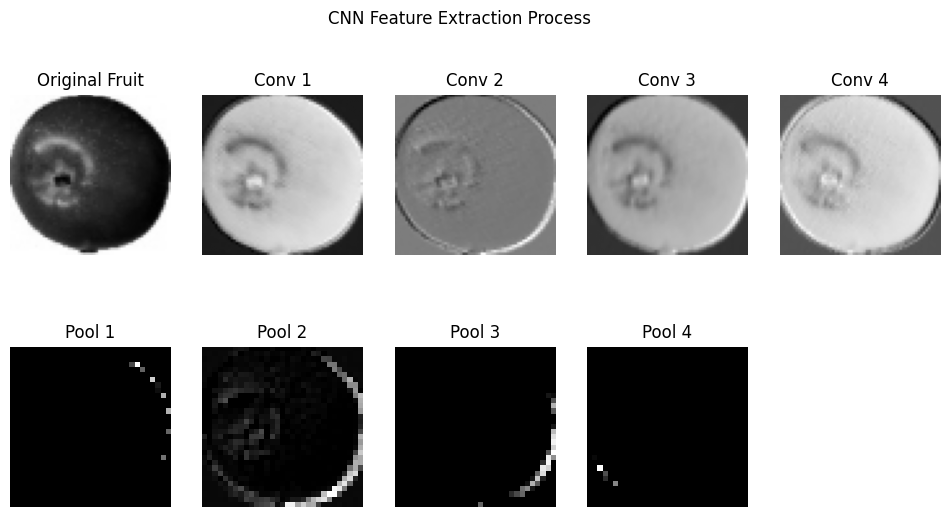

In [28]:
# CNN FEATURE MAP VISUALIZATION

sample = X_test[0:1]

conv_out = conv.forward(sample)
relu_out = relu(conv_out)
pool_out = pool.forward(relu_out)

plt.figure(figsize=(12,6))

plt.subplot(2,5,1)
plt.imshow(sample[0,0],cmap='gray')
plt.title("Original Fruit")
plt.axis("off")

for i in range(4):

    plt.subplot(2,5,i+2)
    plt.imshow(conv_out[0,i],cmap='gray')
    plt.title("Conv "+str(i+1))
    plt.axis("off")

for i in range(4):

    plt.subplot(2,5,i+6)
    plt.imshow(pool_out[0,i],cmap='gray')
    plt.title("Pool "+str(i+1))
    plt.axis("off")

plt.suptitle("CNN Feature Extraction Process")
plt.show()